In [1]:
from pathlib import Path
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from probcs.models.pattern_completion_model import (
    ExpPatternCompletionModel,
    BinaryPatternCompletionModel,
)
from probcs.experiment_running.exc_experiment import (
    center_surround_experiment,
    create_stimuli,
)
import arviz as az
from sklearn.metrics.pairwise import cosine_similarity
from probcs.utils.utils import (
    select_focus_images,
    get_excitatory_images,
    get_natural_images,
)
from probcs.utils.plotting import plot_posterior

seed = 42
rng = np.random.default_rng(seed)

In [2]:
images = get_natural_images()
vmin = images.min()
vmax = images.max()

In [3]:
# patterns = exc_images[[0, 1, 3, 8, 9]]
patterns = images[:10]

In [4]:
patterns.min(), patterns.max()

(-122.34, 150.59)

In [5]:
G_dim = len(patterns)
G_prob = 0.5
I_sigma = 300
# I_sigma = 400
# I_sigma = 300
# I_sigma = 200
patterns_offset = 0

g_x_mapping = np.zeros((G_dim * 9, G_dim)) + 0.05
for j in range(0, G_dim * 9, G_dim):
    for i in range(G_dim):
        g_x_mapping[i + j, i] = 0.8

G_visual_nrows = G_dim
G_visual_ncols = 1
x_visual_nrows = G_dim
x_visual_ncols = 9
n_tune = 1000
n_draws = 1000
n_chains = 4
n_cores = 4

In [6]:
model = BinaryPatternCompletionModel(
    patterns=patterns,
    G_prob=G_prob,
    I_sigma=I_sigma,
    patterns_offset=patterns_offset,
    g_x_mapping=g_x_mapping,
)

In [7]:
model.G_X_mapping

array([[0.8 , 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
       [0.05, 0.8 , 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
       [0.05, 0.05, 0.8 , 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
       [0.05, 0.05, 0.05, 0.8 , 0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
       [0.05, 0.05, 0.05, 0.05, 0.8 , 0.05, 0.05, 0.05, 0.05, 0.05],
       [0.05, 0.05, 0.05, 0.05, 0.05, 0.8 , 0.05, 0.05, 0.05, 0.05],
       [0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.8 , 0.05, 0.05, 0.05],
       [0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.8 , 0.05, 0.05],
       [0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.8 , 0.05],
       [0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.8 ],
       [0.8 , 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
       [0.05, 0.8 , 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
       [0.05, 0.05, 0.8 , 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
       [0.05, 0.05, 0.05, 0.8 , 0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
       [0.05, 0.05, 0.05, 0.05, 0.

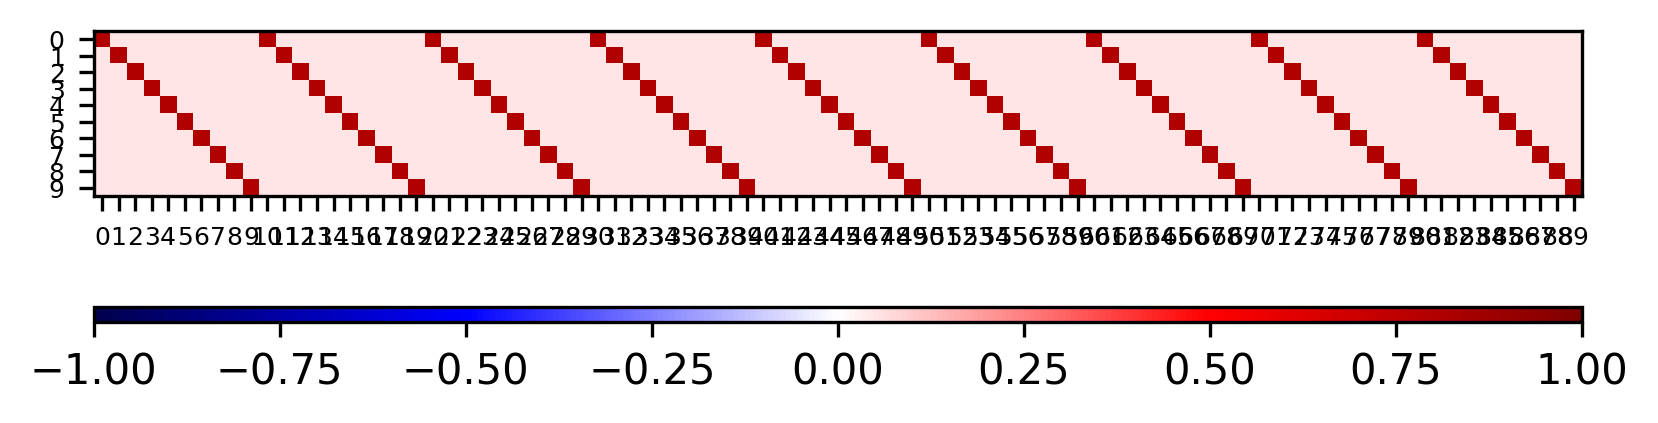

In [8]:
fig, ax = plt.subplots(dpi=300)
ax.imshow(model.G_X_mapping.T, cmap="seismic", vmin=-1, vmax=1)
ax.set_xticks(np.arange(G_dim * 9))
ax.set_xticklabels(np.arange(G_dim * 9))
ax.set_yticks(np.arange(G_dim))
ax.set_yticklabels(np.arange(G_dim))
ax.tick_params(axis="both", which="major", labelsize=6)
# draw a small horizontal colorbar
cbar = fig.colorbar(
    ax.get_images()[0], ax=ax, orientation="horizontal", pad=0.1, aspect=100
)

In [9]:
cossim = cosine_similarity(model.patterns.reshape(model.patterns.shape[0], -1))

Text(0.5, 1.0, 'Cos sim between assigned Gs')

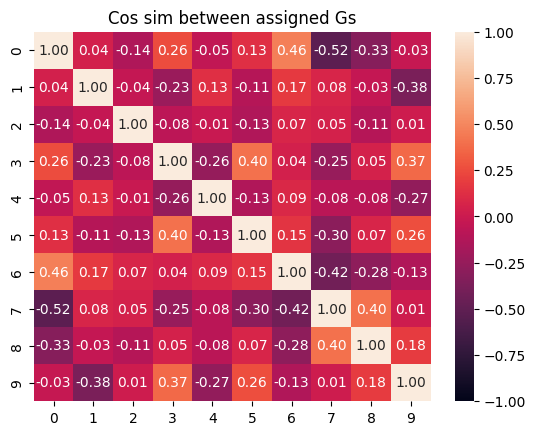

In [10]:
fig, ax = plt.subplots(dpi=100)
sns.heatmap(cossim, vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax)
ax.set_title("Cos sim between assigned Gs")

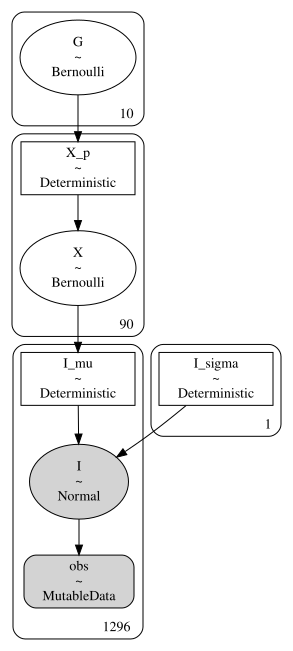

In [11]:
pm.model_to_graphviz(model.prob_model)

In [12]:
prior_samples_dict = model.sample_prior_predictive(n_samples=100, random_seed=1)

Sampling: [G, I, X]


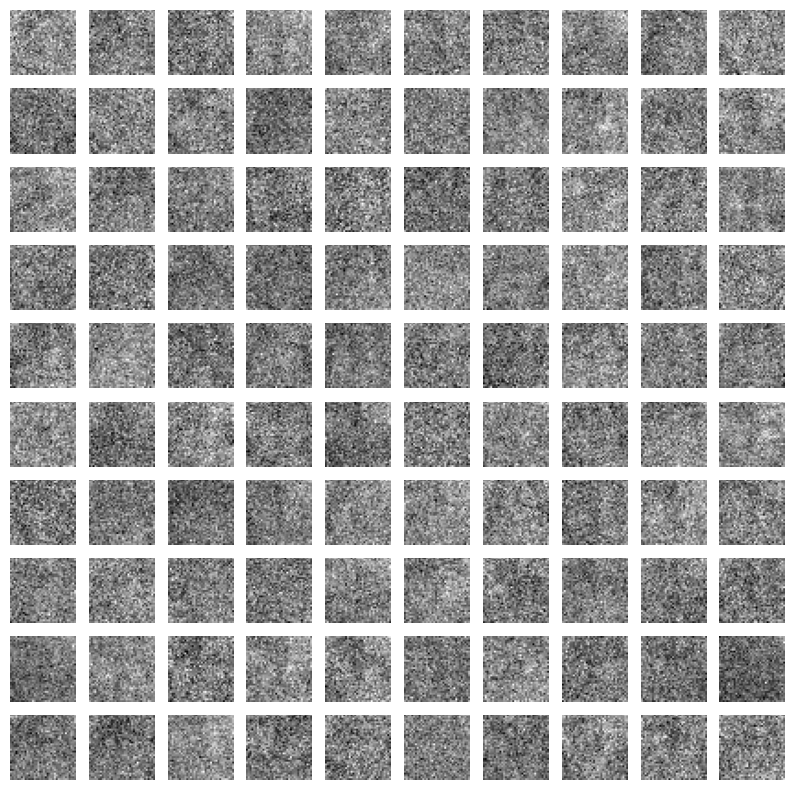

In [13]:
fig, axs = plt.subplots(10, 10, figsize=(10, 10))
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(prior_samples_dict["I"][idx], cmap="gray")
    ax.axis("off")

In [14]:
(
    MEIs,
    completing_patterns,
    disrupting_patterns_1,
    disrupting_patterns_2,
    disrupting_pattern_indices,
) = create_stimuli(patterns)

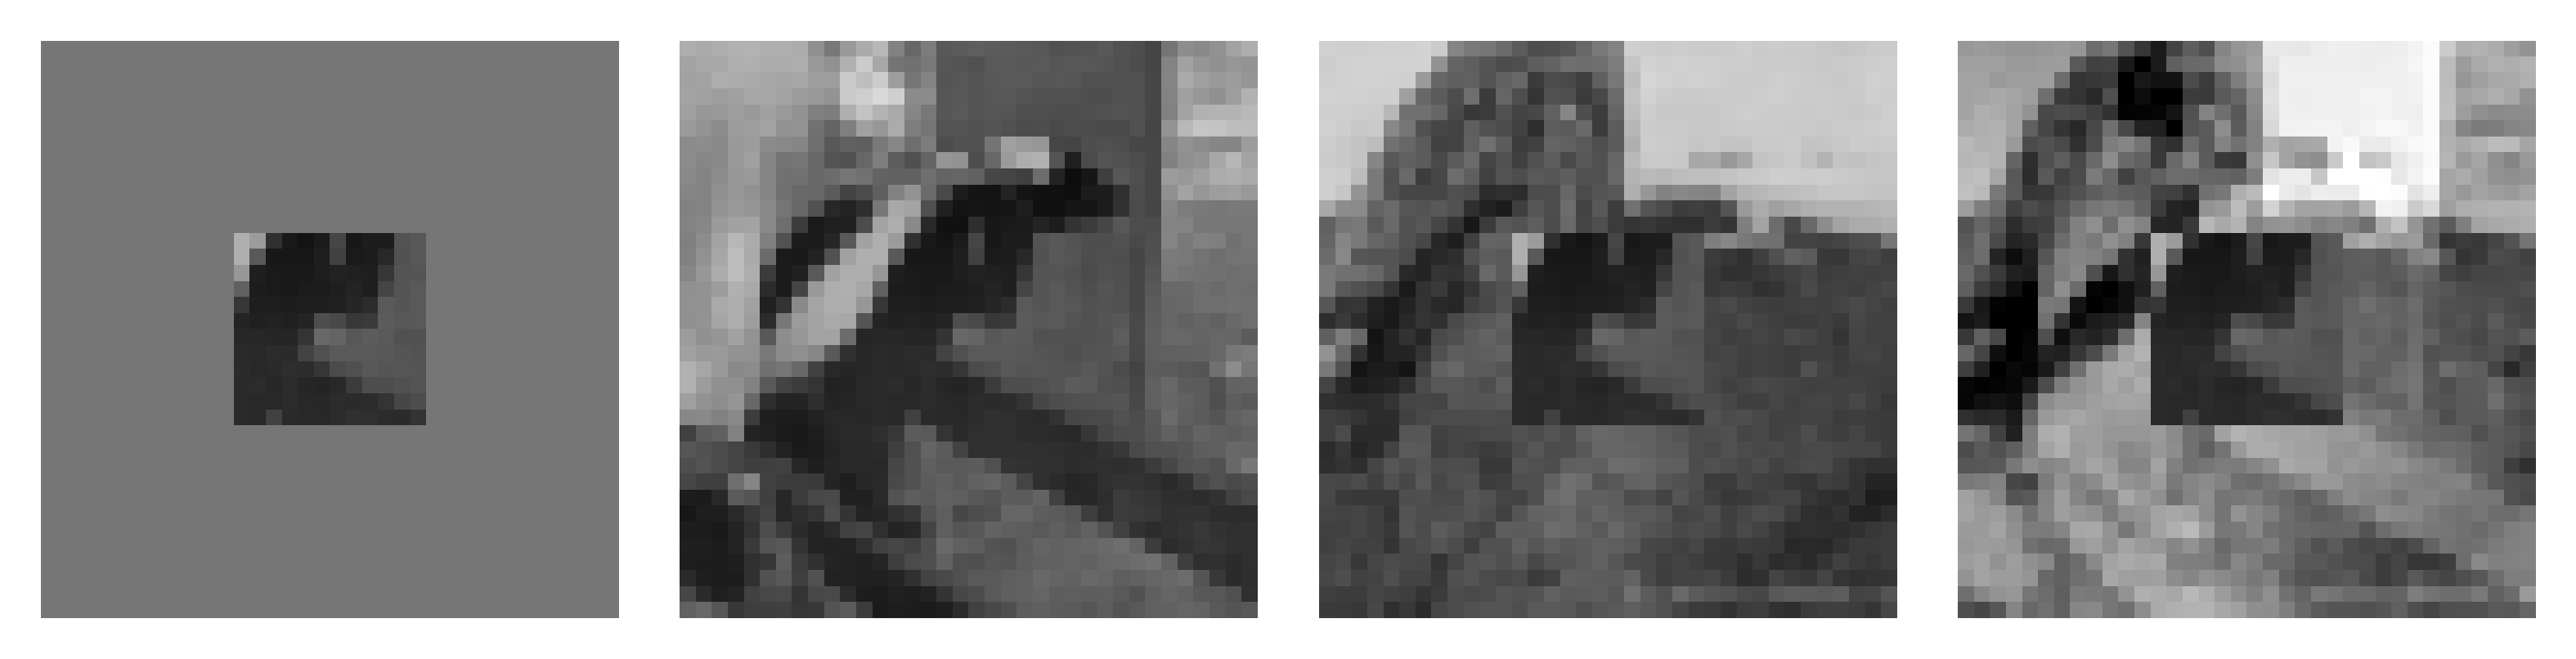

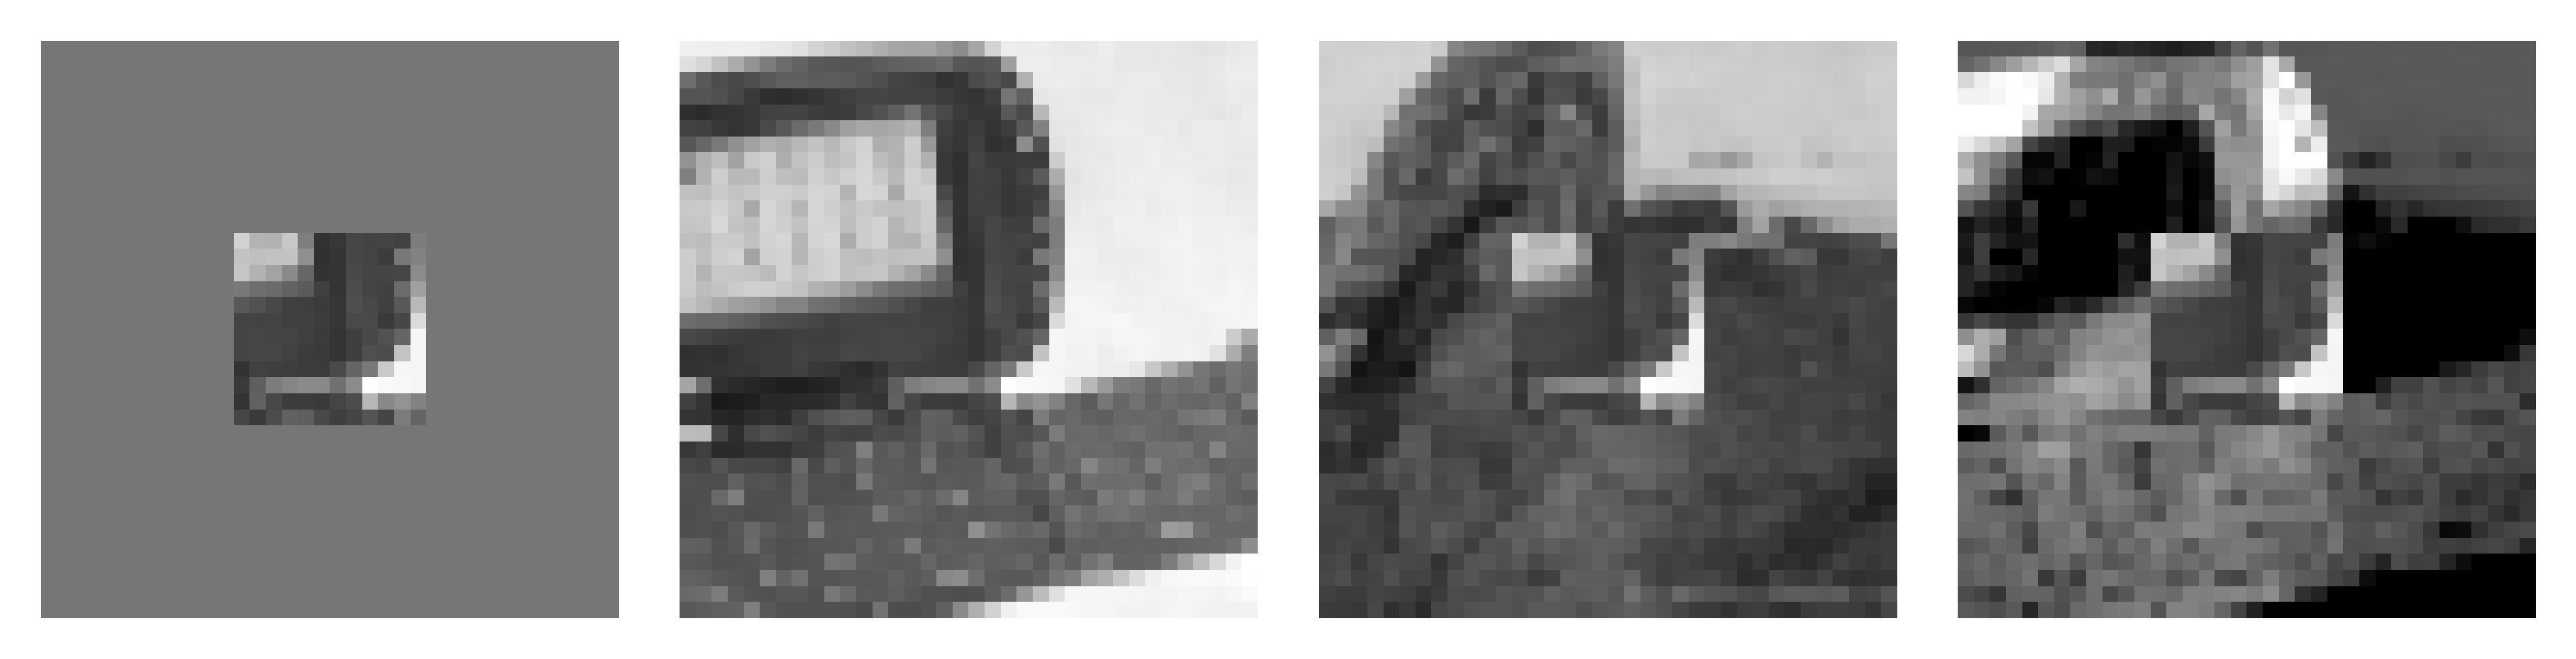

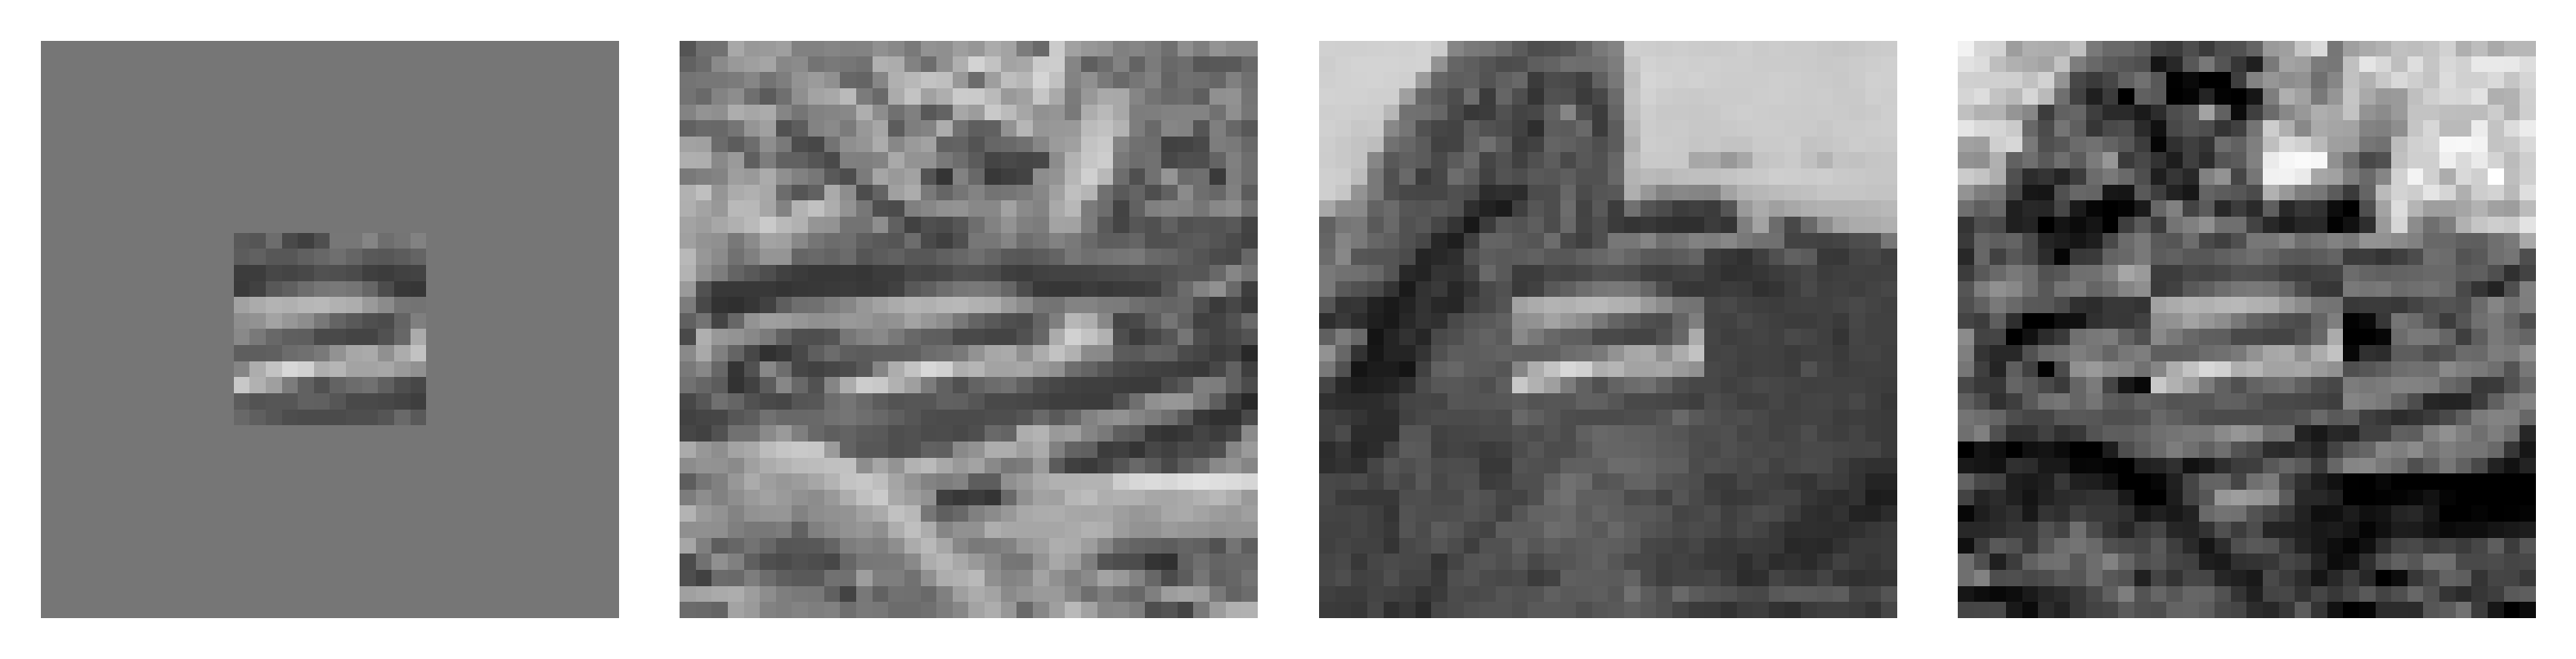

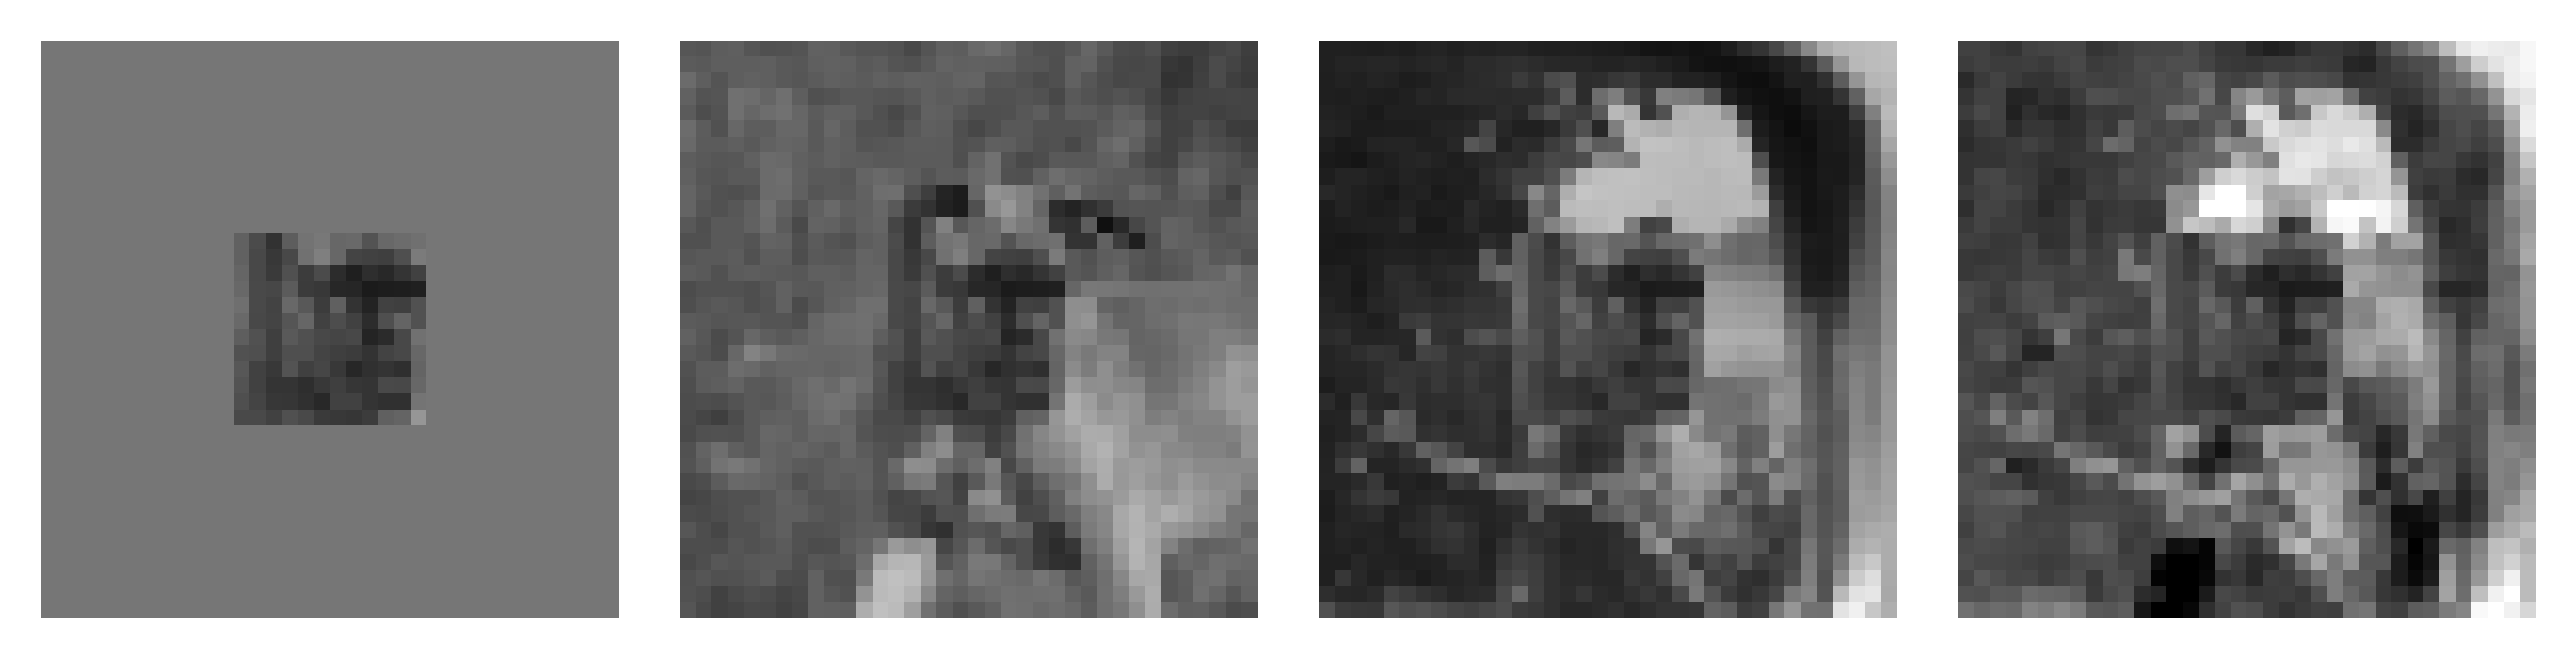

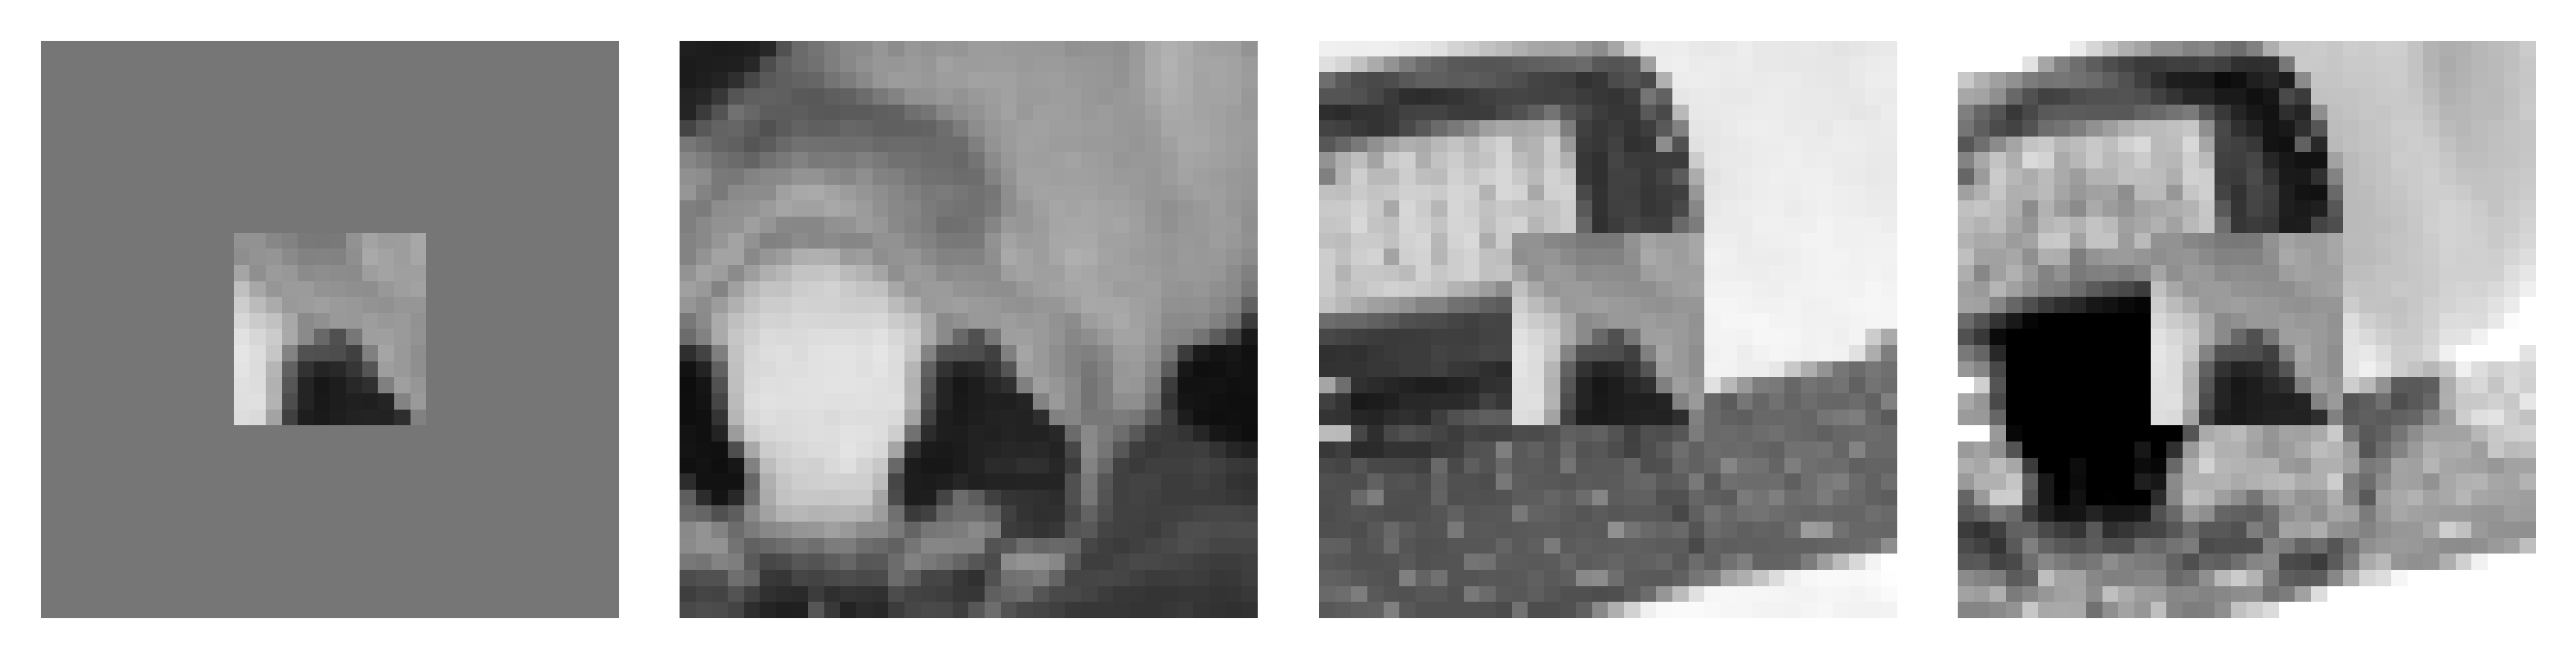

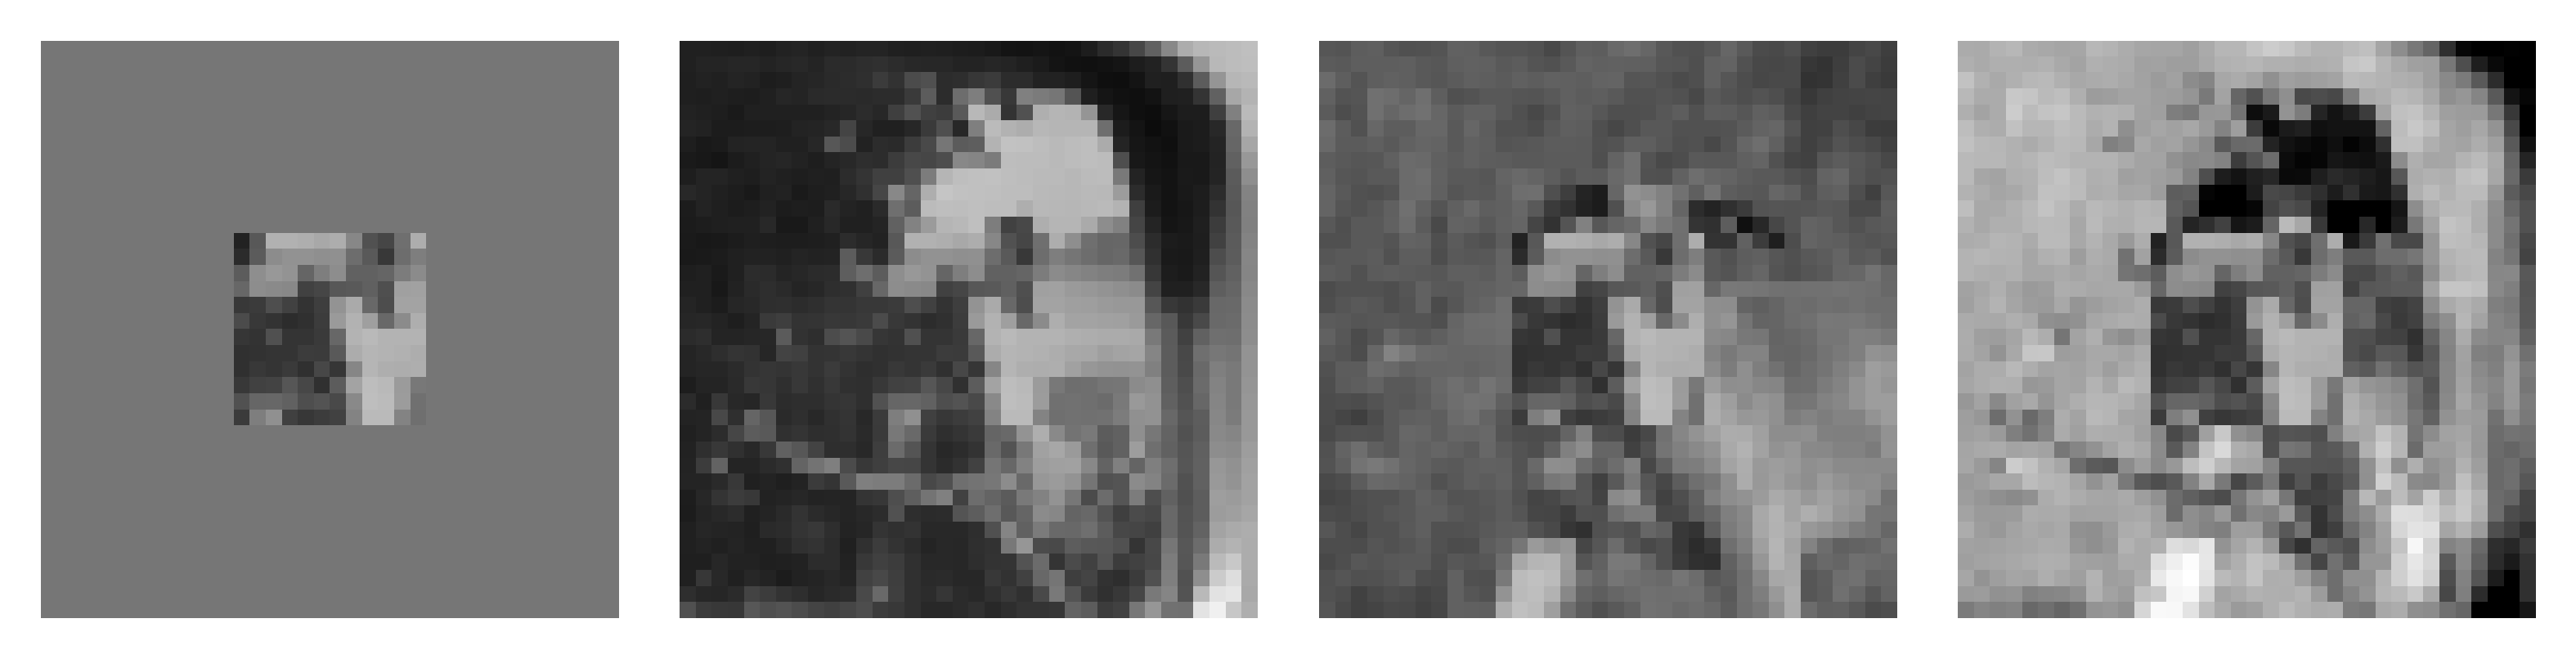

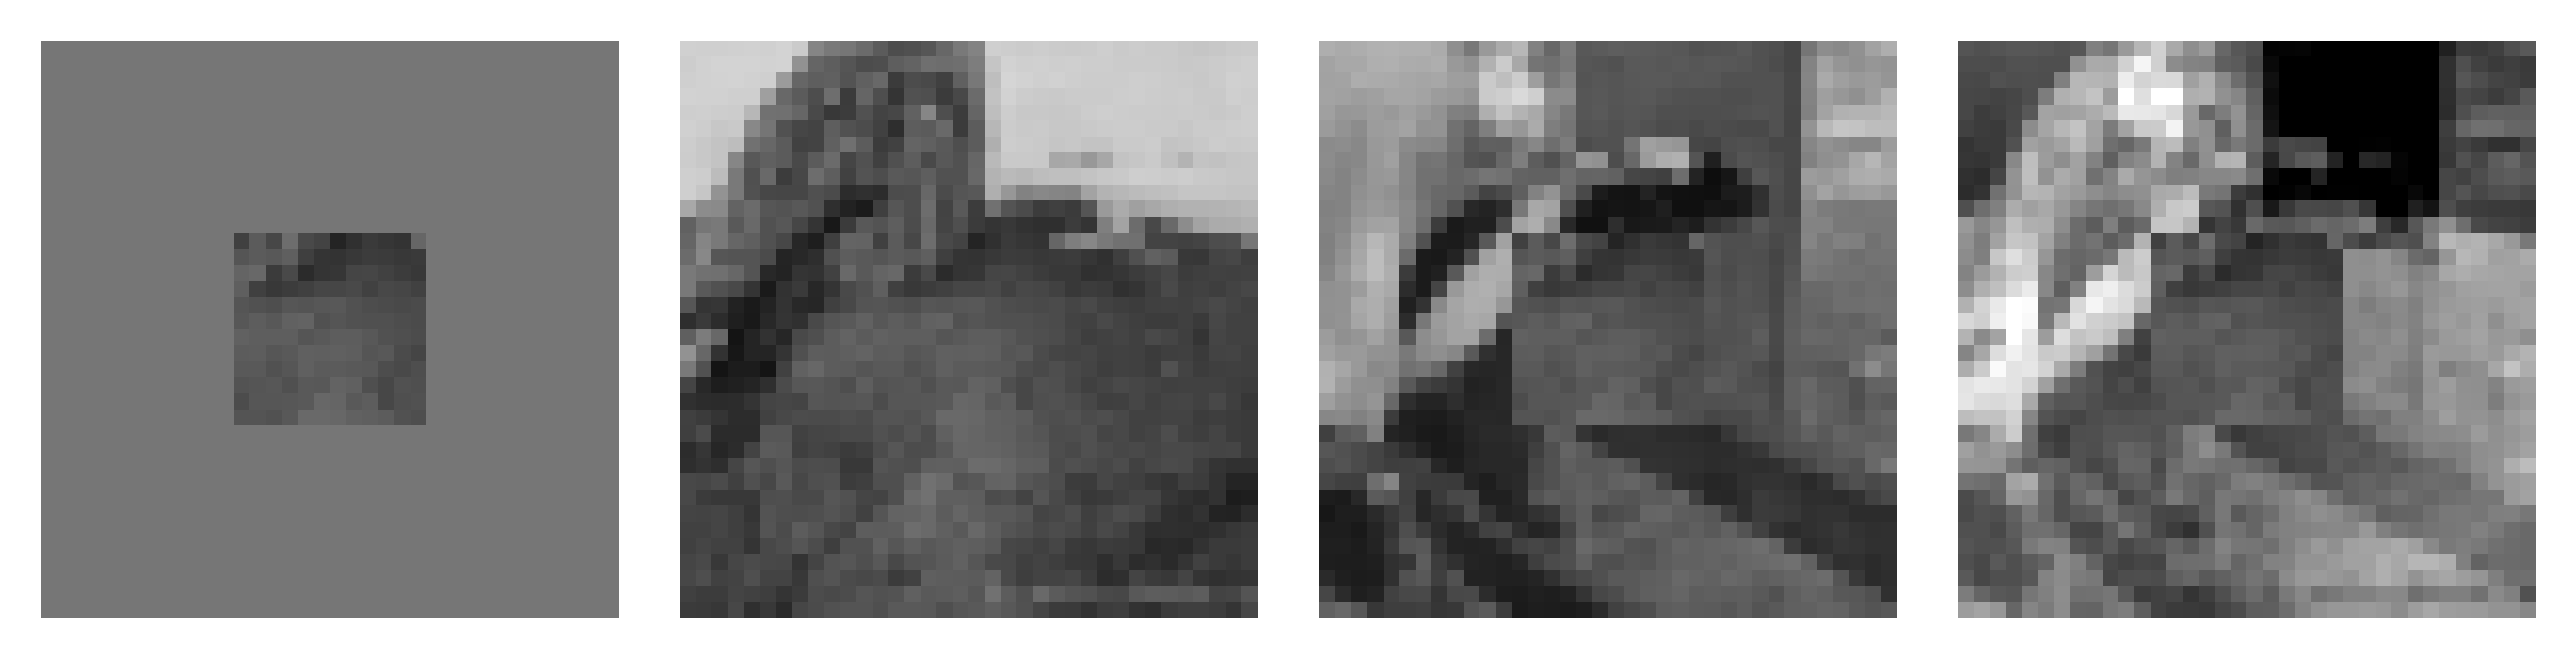

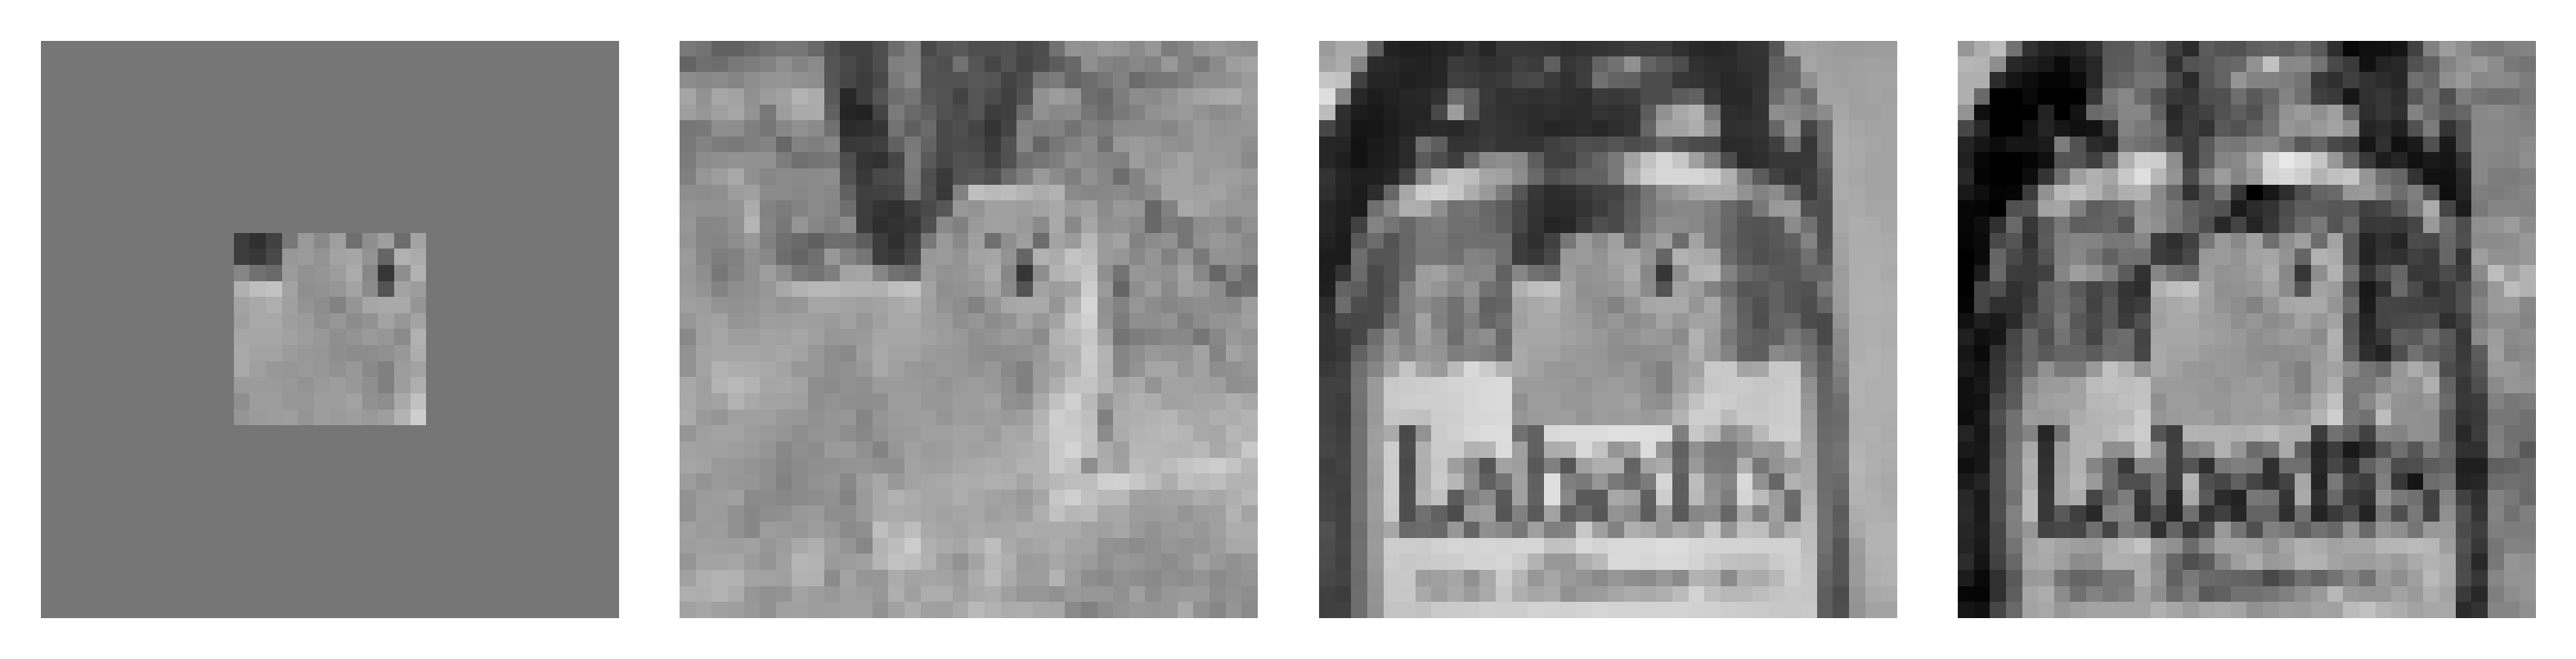

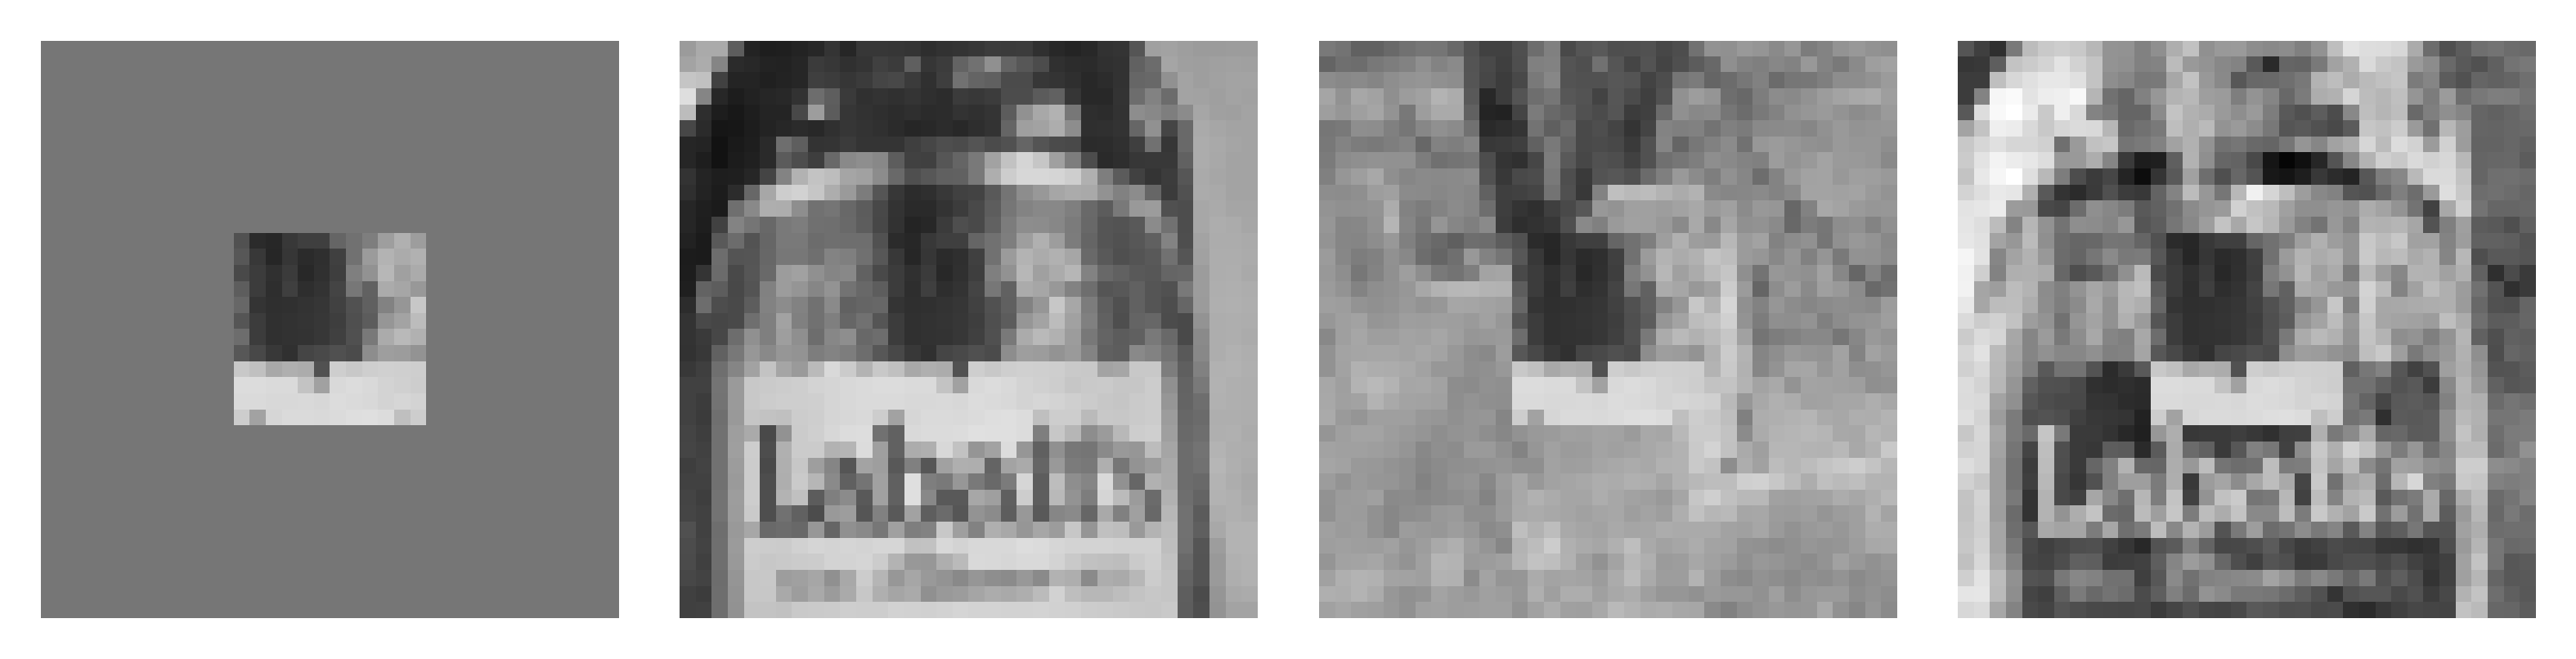

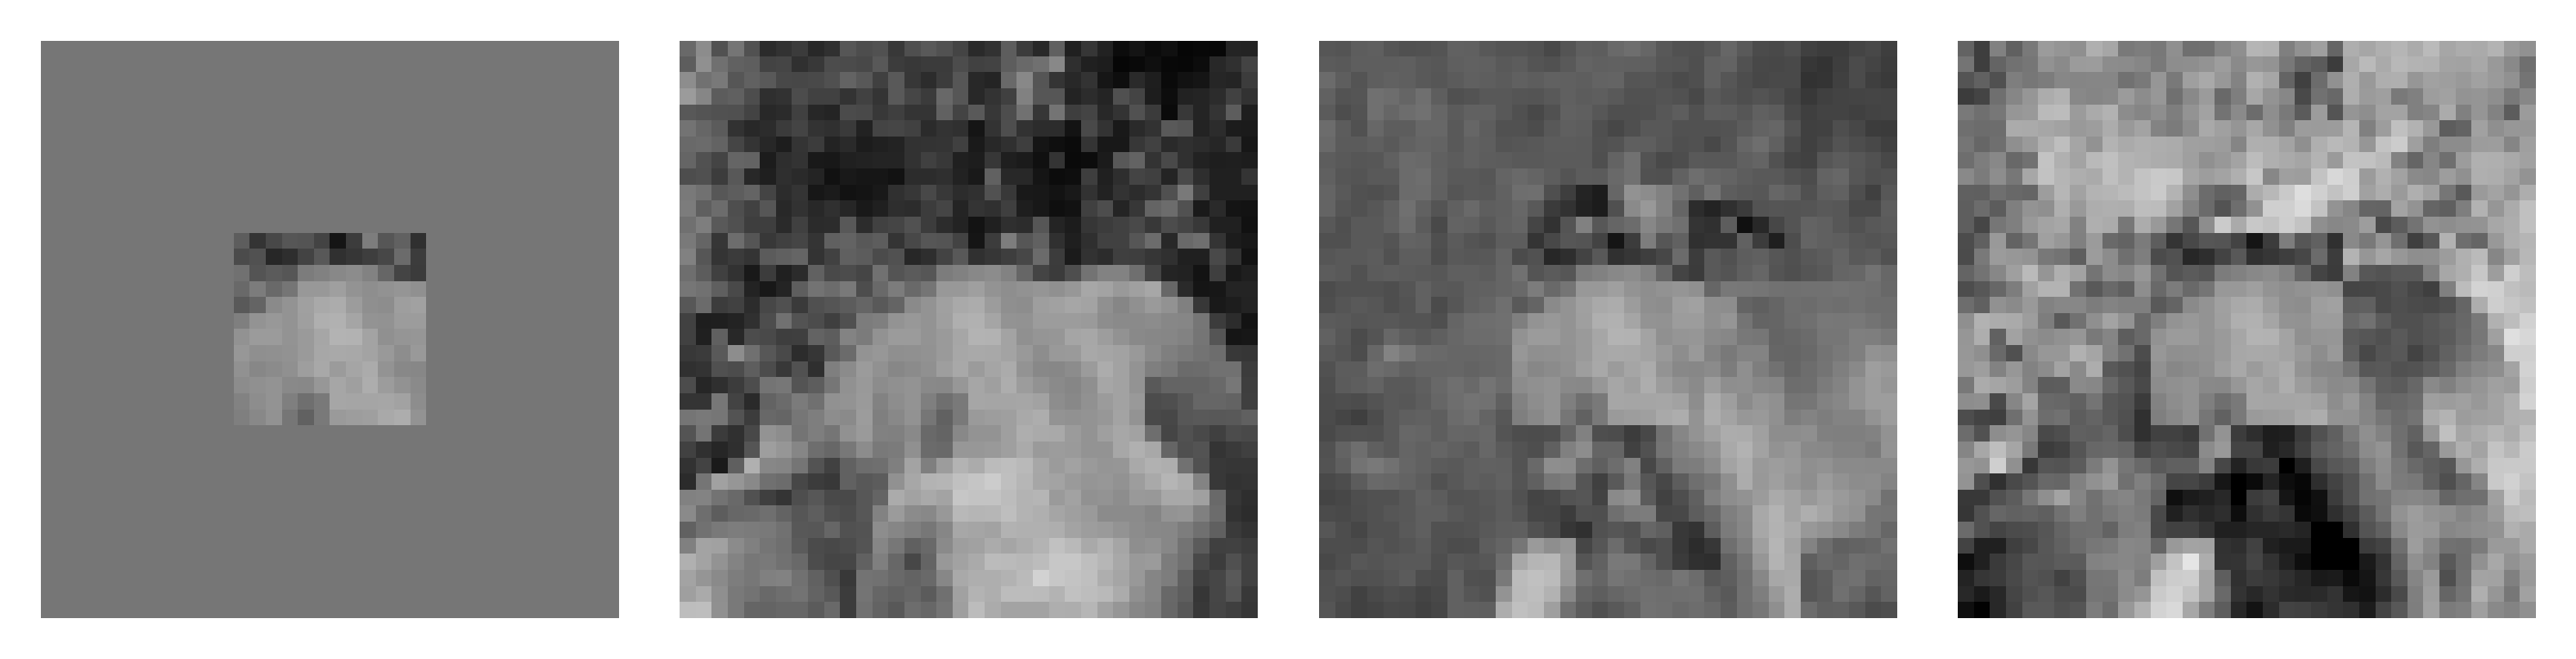

In [15]:
for idx, (
    MEI,
    completing_pattern,
    disrupting_pattern_1,
    disrupting_pattern_2,
) in enumerate(
    zip(MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2)
):
    fig, axs = plt.subplots(1, 4, dpi=500)
    axs[0].imshow(MEI, cmap="gray", vmin=vmin, vmax=vmax)
    axs[0].axis("off")
    axs[1].imshow(completing_pattern, cmap="gray", vmin=vmin, vmax=vmax)
    axs[1].axis("off")
    axs[2].imshow(disrupting_pattern_1, cmap="gray", vmin=vmin, vmax=vmax)
    axs[2].axis("off")
    axs[3].imshow(disrupting_pattern_2, cmap="gray", vmin=vmin, vmax=vmax)
    axs[3].axis("off")
    fig.tight_layout()
    fig.savefig(f"stimuli_{idx}.pdf")

In [16]:
all_idata = []
for MEI, completing_pattern, disrupting_pattern_1, disrupting_pattern_2 in zip(
    MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2
):
    idata_set = []
    idata = model(
        image=MEI,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed,
    )
    idata_set.append(idata)
    idata = model(
        image=completing_pattern,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed,
    )
    idata_set.append(idata)
    idata = model(
        image=disrupting_pattern_1,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed,
    )
    idata_set.append(idata)
    idata = model(
        image=disrupting_pattern_2,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed,
    )
    idata_set.append(idata)
    all_idata.append(idata_set)
    # The `break` statement in the code snippet provided is used to exit the loop prematurely. In this case, the `break` statement is placed after appending the `idata_set` to `all_idata`, which means that the loop will only run once for the first set of data and then exit immediately after processing that set. This results in only one iteration of the loop being executed before the loop is terminated.
    # break

Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 146 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: divide by zero encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 150 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 147 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 150 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 147 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 150 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 141 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 142 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 147 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [17]:
def plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata):
    """
    Modified function to plot bar plots of MEI, Completing, and Disrupting patterns for binary X
    in the same subplot for each latent variable G.

    Parameters:
    - G_dim (int): Dimension of the latent variable G.
    - disrupting_pattern_indices (list): List of indices corresponding to disrupting patterns.
    - all_idata (list): List containing InferenceData objects for MEI, Completing, and Disrupting 1 and Disrupting 2 patterns.

    Returns:
    - fig (matplotlib.figure.Figure): The Matplotlib figure object containing the generated plot.
    - axs (numpy.ndarray): 2D array of Matplotlib axes objects representing subplots in the figure.
    - completing_perc_diff_list (list): List of percentage differences for Completing.
    - disrupting_1_perc_diff_list (list): List of percentage differences for Disrupting 1.
    - disrupting_2_perc_diff_list (list): List of percentage differences for Disrupting 2.
    """

    fig, axs = plt.subplots(
        G_dim, 6, figsize=(6 * 8, 3 * 4), tight_layout=True, sharex="col", sharey="row"
    )
    legend_size = 6

    completing_perc_diff_list = []
    disrupting_1_perc_diff_list = []
    disrupting_2_perc_diff_list = []

    for idx, (ax_set, idata_set, disrupting_pattern_idx) in enumerate(
        zip(axs, all_idata, disrupting_pattern_indices)
    ):
        center_x_id = 4 * G_dim + idx

        # Collect probabilities for MEI, Completing, and Disrupting patterns
        center_probabilities = []
        all_probabilities = []
        for pattern_id, idata in enumerate(idata_set):
            x_prob = idata["posterior"]["X"].data[:, :, center_x_id].mean()
            center_probabilities.append(x_prob)
            all_x_prob = idata["posterior"]["X"].data.mean(axis=0).mean(axis=0)
            all_probabilities.append(all_x_prob)

            if pattern_id == 0:
                mei_x_prob = x_prob
            elif pattern_id > 0:
                perc_diff = (x_prob - mei_x_prob) / mei_x_prob * 100
                if pattern_id == 1:
                    completing_perc_diff_list.append(perc_diff)
                elif pattern_id == 2:
                    disrupting_1_perc_diff_list.append(perc_diff)
                elif pattern_id == 3:
                    disrupting_2_perc_diff_list.append(perc_diff)
            # if idx == 3:
            #     print(idata["posterior"]["X"].data[:, :, center_x_id])
            #     print(center_probabilities)

        # Plot center_probabilities in the same subplot for comparison
        ax_set[0].bar(
            ["MEI", "Completing", "Disrupting 1", "Disrupting 2"],
            center_probabilities,
            color=["blue", "green", "orange", "red"],
        )
        ax_set[0].set_ylim(0, 1)  # Probabilities range from 0 to 1

        # Plot all_probabilities in the same subplot for comparison
        for idx, probs in enumerate(all_probabilities):
            ax_set[2 + idx].bar(
                list(range(G_dim * 9)),
                probs,
                color=["red" if i == center_x_id else "blue" for i in range(G_dim * 9)],
            )
            ax_set[2 + idx].set_xticks(list(range(G_dim * 9)))
            ax_set[2 + idx].set_xticklabels(list(range(G_dim * 9)))

        # Plot G distributions (unchanged)
        mei_g_samples = idata_set[0]["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        completing_g_samples = (
            idata_set[1]["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        )
        disrupting_1_g_samples = (
            idata_set[2]["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        )
        disrupting_2_g_samples = (
            idata_set[3]["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        )

        ax_set[1].bar(x=np.arange(G_dim), height=mei_g_samples, width=0.8, color="blue")
        ax_set[1].bar(
            x=np.arange(G_dim) + G_dim,
            height=completing_g_samples,
            width=0.8,
            color="green",
        )
        ax_set[1].bar(
            x=np.arange(G_dim) + G_dim * 2,
            height=disrupting_1_g_samples,
            width=0.8,
            color="orange",
        )
        ax_set[1].bar(
            x=np.arange(G_dim) + G_dim * 3,
            height=disrupting_2_g_samples,
            width=0.8,
            color="red",
        )
        ax_set[1].set_xticks(np.arange(G_dim * 4))
        ax_set[1].set_xticklabels(list(np.arange(G_dim)) * 4)

    completing_perc_diff_list = np.array(completing_perc_diff_list)
    disrupting_1_perc_diff_list = np.array(disrupting_1_perc_diff_list)
    disrupting_2_perc_diff_list = np.array(disrupting_2_perc_diff_list)

    return (
        fig,
        axs,
        completing_perc_diff_list,
        disrupting_1_perc_diff_list,
        disrupting_2_perc_diff_list,
    )

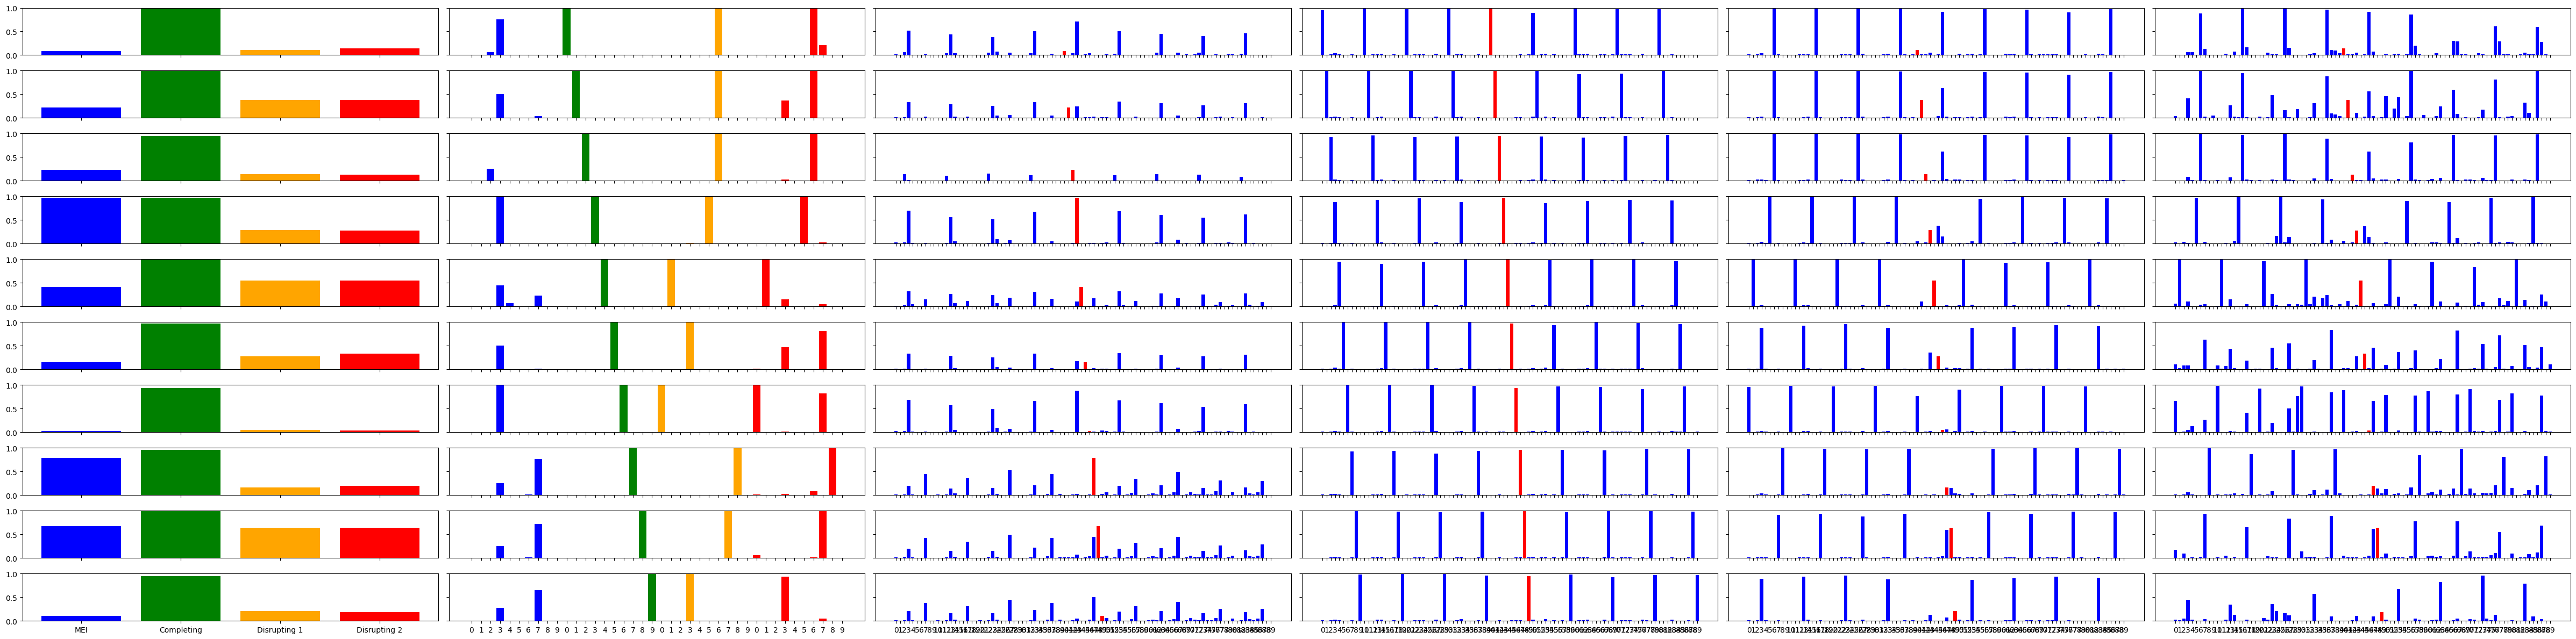

In [18]:
(
    fig,
    axs,
    completing_perc_diff_list,
    disrupting_1_perc_diff_list,
    disrupting_2_perc_diff_list,
) = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

In [19]:
results = [all_idata, G_dim, disrupting_pattern_indices]
import pickle

with open(f"results_natural_{G_dim}_{n_draws}_{I_sigma}.pkl", "wb") as f:
    pickle.dump(results, f)

In [20]:
# with open(f"results_natural_{G_dim}_{n_draws}.pkl", "rb") as f:
#     results = pickle.load(f)

In [21]:
completing_perc_diff_list

array([ 1.12123077e+03,  3.53960964e+02,  2.99894068e+02, -2.04970535e-01,
        1.41158537e+02,  5.57672850e+02,  2.89120000e+03,  2.11258697e+01,
        4.91398654e+01,  7.71990741e+02])

In [22]:
disrupting_1_perc_diff_list

array([ 27.69230769,  76.92307692, -39.30084746, -69.99743787,
        35.        ,  88.02698145,  55.2       , -79.19038583,
        -3.44053852,  87.73148148])

In [23]:
disrupting_pattern_indices

[6, 6, 6, 5, 1, 3, 0, 8, 7, 3]